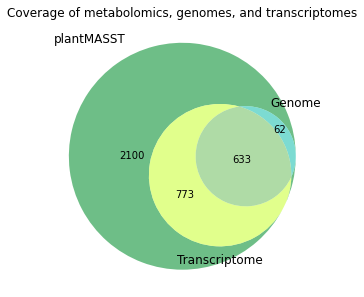

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


# Read your table
df = pd.read_csv(
    '/path/coverage_metabolomics_genomics_transcriptomics.txt',
    sep="\t"
)

# Define sets
plant = set(df["plantMASST"].dropna())
genome = set(df["NCBI_Genome"].dropna())
transc = set(df["Transcriptome"].dropna())

# Region sizes
A_only  = len(plant - genome - transc)                 # plantMASST only
B_only  = 0                                            # Genome only
C_only  = 0                                            # Transcriptome only
AB_only = len((plant & genome) - transc)               # plantMASST ∩ Genome
AC_only = len((plant & transc) - genome)               # plantMASST ∩ Transcriptome
BC_only = 0                                            # Genome ∩ Transcriptome only
ABC     = len(plant & genome & transc)                 # all three

subsets = (A_only, B_only, AB_only,
           C_only, AC_only, BC_only,
           ABC)

# White background
fig = plt.figure(figsize=(5, 5), facecolor="white")
ax = fig.add_subplot(111)
ax.set_facecolor("white")

v = venn3(
    subsets=subsets,
    set_labels=("plantMASST", "Genome", "Transcriptome"),
    set_colors=("#31a354",  # green  (plantMASST)
                "#3182bd",  # blue   (Genome)
                "#ffd92f")  # yellow (Transcriptome)
)

# Make patches slightly transparent so overlaps are readable
for patch in v.patches:
    if patch is not None:
        patch.set_alpha(0.7)

plt.title("Coverage of metabolomics, genomes, and transcriptomes")
plt.tight_layout()
plt.savefig('/path/coverage_metabolomics_genomics_transcriptomics.pdf')
plt.show()
